In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

In [2]:
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root"
batch = EDM4hepEventBatch(edm_input_file, events=(0, 10), full_load=False)

In [3]:
particles = batch.get_particles_df()

In [4]:
generator_particles = particles[particles["created_in_simulation"] == False]
generator_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,...,6999.999937,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,0,1,1,0,-0.333333,-0.221602,0.00000,-0.011325,-0.007458,116.524419,...,855.719020,0,1,0.013560,855.719020,855.719020,1,False,0,0
2,0,2,2,0,0.666667,-0.221602,0.33000,-0.011325,-0.007458,116.524419,...,1052.295476,1,2,0.013560,1052.295527,1051.965527,2,False,0,0
3,0,3,2103,0,0.333333,-0.221602,0.77133,-0.011325,-0.007458,116.524419,...,2005.069087,2,3,0.013560,2005.069235,2004.297905,3,False,0,0
4,0,4,-1,0,0.333333,-0.221602,0.33000,-0.011325,-0.007458,116.524419,...,3086.916278,3,4,0.013560,3086.916295,3086.586295,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2112632,9,93338,310,0,0.000000,0.400682,0.49761,0.025793,0.003278,52.052604,...,-5.997176,268563,268564,0.026000,6.019028,5.521418,93338,False,0,0
2112633,9,93339,22,16777216,0.000000,0.400683,0.00000,0.025762,0.003214,52.052311,...,-0.268228,268564,268565,0.025961,0.277790,0.277790,93339,False,0,0
2112634,9,93340,22,16777216,0.000000,0.400683,0.00000,0.025762,0.003214,52.052311,...,-1.606659,268565,268566,0.025961,1.652154,1.652154,93340,False,0,0
2112635,9,93341,211,33554432,1.000000,1.868946,0.13957,-8.736305,-1.787310,-386.523638,...,-3.671893,268566,268567,8.917259,3.676882,3.537312,93341,False,0,0


In [5]:
generator_particles[generator_particles.particle_id == 1]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
1,0,1,1,0,-0.333333,-0.221602,0.0,-0.011325,-0.007458,116.524419,...,855.719020,0,1,0.013560,855.719020,855.719020,1,False,0,0
184996,1,1,2,0,0.666667,5.616343,0.0,-0.012894,-0.001564,44.930555,...,825.389603,0,1,0.012988,825.389603,825.389603,1,False,0,0
356534,2,1,2,0,0.666667,-11.763285,0.0,-0.003474,-0.011916,-57.315237,...,2023.975197,0,1,0.012412,2023.975197,2023.975197,1,False,0,0
542755,3,1,21,0,0.000000,-8.741320,0.0,-0.014461,0.002710,65.368268,...,133.251010,0,1,0.014713,133.251010,133.251010,1,False,0,0
741962,4,1,2,0,0.666667,0.570068,0.0,0.015169,0.014099,105.732626,...,777.415245,0,1,0.020710,777.415245,777.415245,1,False,0,0
986661,5,1,2,0,0.666667,0.459271,0.0,0.003587,0.004667,-99.311206,...,3188.498980,0,1,0.005886,3188.498980,3188.498980,1,False,0,0
1254519,6,1,21,0,0.000000,0.021734,0.0,0.010893,-0.037676,-84.350306,...,468.937541,0,1,0.039219,468.937541,468.937541,1,False,0,0
1510956,7,1,21,0,0.000000,1.811314,0.0,0.026831,0.004945,44.982809,...,579.512323,0,1,0.027283,579.512323,579.512323,1,False,0,0
1814362,8,1,2,0,0.666667,7.694633,0.0,-0.010178,0.010418,35.407554,...,609.448139,0,1,0.014565,609.448139,609.448139,1,False,0,0
2019295,9,1,1,0,-0.333333,1.754684,0.0,0.009693,-0.020522,-8.414291,...,1699.147149,0,1,0.022696,1699.147149,1699.147149,1,False,0,0


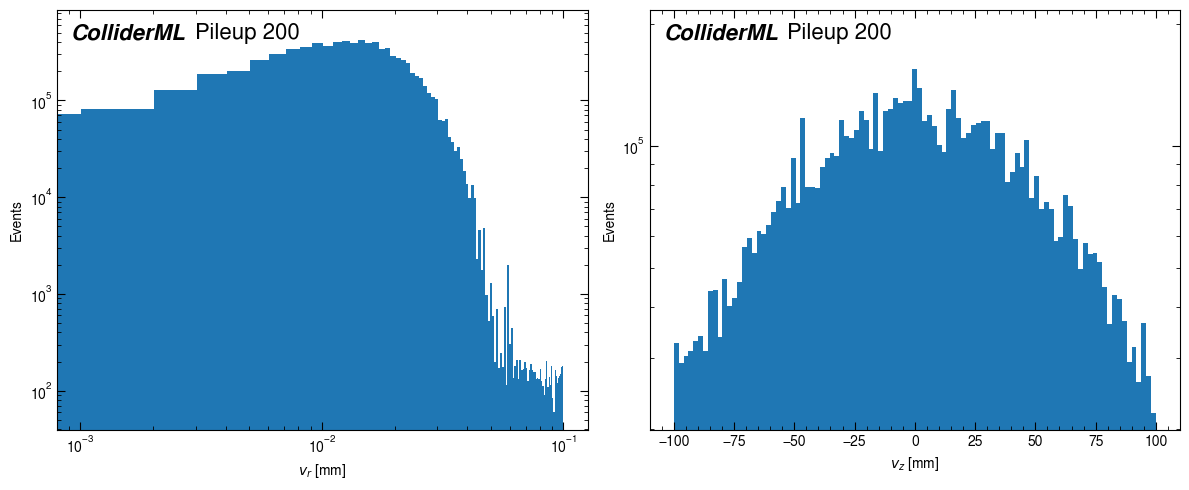

In [33]:
# Plot vr and vz distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate vr from vx and vy
vr = np.sqrt(generator_particles["vx"]**2 + generator_particles["vy"]**2)

# Plot vr
bins_r = np.linspace(0, 0.1, 100)
counts_r = np.histogram(vr, bins=bins_r)[0]
axes[0].bar(bins_r[:-1], counts_r, width=bins_r[1]-bins_r[0], align='edge')
axes[0].set_xlabel("$v_r$ [mm]")
axes[0].set_ylabel("Events")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
atl.atlasify("Pileup 200", axes=axes[0])

# Plot vz
bins_z = np.linspace(-100, 100, 100)
counts_z = np.histogram(generator_particles["vz"], bins=bins_z)[0]
axes[1].bar(bins_z[:-1], counts_z, width=bins_z[1]-bins_z[0], align='edge')
axes[1].set_xlabel("$v_z$ [mm]")
axes[1].set_ylabel("Events")
axes[1].set_yscale("log")
atl.atlasify("Pileup 200", axes=axes[1])

plt.tight_layout()
plt.show()


In [13]:
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root"
hard_scatter_batch = EDM4hepEventBatch(edm_input_file, events=(0, 100), full_load=False)

In [14]:
hard_scatter_particles = hard_scatter_batch.get_particles_df()

In [15]:
hard_scatter_generator_particles = hard_scatter_particles[hard_scatter_particles["created_in_simulation"] == False]
hard_scatter_generator_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,-3.158825,0.93827,-0.010798,0.010474,55.597823,...,6999.999937,0,0,0.015043,7000.000000,6999.061730,0,False,0,0
1,0,1,21,0,0.000000,-3.158825,0.00000,-0.010798,0.010474,55.597823,...,1210.616972,0,1,0.015043,1210.616972,1210.616972,1,False,0,0
2,0,2,2,0,0.666667,-3.158825,0.33000,-0.010798,0.010474,55.597823,...,3436.204368,1,2,0.015043,3436.204384,3435.874384,2,False,0,0
3,0,3,2103,0,0.333333,-3.158825,0.77133,-0.010798,0.010474,55.597823,...,2353.178474,2,3,0.015043,2353.178600,2352.407270,3,False,0,0
4,0,4,2212,0,1.000000,-3.158825,0.93827,-0.010798,0.010474,55.597823,...,-6999.999937,3,3,0.015043,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184257,31,854,310,0,0.000000,0.709747,0.49761,-0.673387,-0.406543,-33.500397,...,1.175173,3366,3367,0.786593,2.273084,1.775474,854,False,0,0
184258,31,855,-321,16777216,-1.000000,0.715983,0.49368,-2.064625,-1.262374,-32.607505,...,4.640614,3367,3368,2.419972,9.261747,8.768067,855,False,0,0
184259,31,856,111,0,0.000000,0.715983,0.13498,-2.064625,-1.262374,-32.607505,...,1.633264,3368,3369,2.419972,4.383844,4.248864,856,False,0,0
184260,31,857,111,0,0.000000,1.434791,0.13498,-158.053006,-87.502687,78.874959,...,0.545708,3369,3370,180.658443,1.104404,0.969424,857,False,0,0


In [16]:
hard_scatter_generator_particles[hard_scatter_generator_particles.particle_id == 1]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
1,0,1,21,0,0.000000,-3.158825,0.0,-0.010798,0.010474,55.597823,...,1210.616972,0,1,0.015043,1210.616972,1210.616972,1,False,0,0
2018,1,1,3,0,-0.333333,-3.089242,0.0,0.009854,0.006512,-20.294579,...,159.195211,0,1,0.011811,159.195211,159.195211,1,False,0,0
4786,2,1,21,0,0.000000,0.854968,0.0,-0.002063,0.001480,-1.236146,...,108.645622,0,1,0.002539,108.645622,108.645622,1,False,0,0
8011,3,1,21,0,0.000000,-1.079534,0.0,-0.007302,-0.006482,32.712812,...,326.818203,0,1,0.009764,326.818203,326.818203,1,False,0,0
10328,4,1,21,0,0.000000,-9.157588,0.0,-0.005959,0.007364,72.532876,...,1195.934331,0,1,0.009473,1195.934331,1195.934331,1,False,0,0
14960,5,1,21,0,0.000000,-1.160841,0.0,0.002555,0.004712,-36.549513,...,2923.400733,0,1,0.005361,2923.400733,2923.400733,1,False,0,0
20729,6,1,21,0,0.000000,0.236390,0.0,0.005884,-0.004825,-6.708458,...,1041.534115,0,1,0.007609,1041.534115,1041.534115,1,False,0,0
27846,7,1,1,0,-0.333333,-4.309833,0.0,-0.007633,0.011669,61.603767,...,664.009724,0,1,0.013944,664.009724,664.009724,1,False,0,0
35942,8,1,1,0,-0.333333,-0.014915,0.0,0.017001,0.009420,-23.804272,...,808.874476,0,1,0.019437,808.874476,808.874476,1,False,0,0
41839,9,1,21,0,0.000000,-5.802359,0.0,0.014476,0.012597,-56.033629,...,934.783677,0,1,0.019190,934.783677,934.783677,1,False,0,0


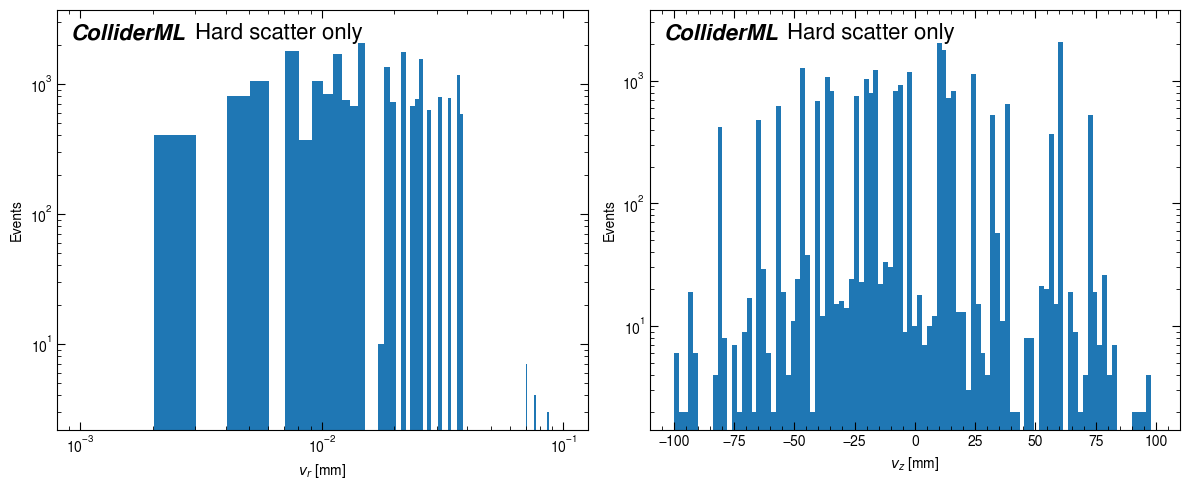

In [17]:
# Plot vr and vz distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate vr from vx and vy
vr = np.sqrt(hard_scatter_generator_particles["vx"]**2 + hard_scatter_generator_particles["vy"]**2)

# Plot vr
bins_r = np.linspace(0, 0.1, 100)
counts_r = np.histogram(vr, bins=bins_r)[0]
axes[0].bar(bins_r[:-1], counts_r, width=bins_r[1]-bins_r[0], align='edge')
axes[0].set_xlabel("$v_r$ [mm]")
axes[0].set_ylabel("Events")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
atl.atlasify("Hard scatter only", axes=axes[0])

# Plot vz
bins_z = np.linspace(-100, 100, 100)
counts_z = np.histogram(hard_scatter_generator_particles["vz"], bins=bins_z)[0]
axes[1].bar(bins_z[:-1], counts_z, width=bins_z[1]-bins_z[0], align='edge')
axes[1].set_xlabel("$v_z$ [mm]")
axes[1].set_ylabel("Events")
axes[1].set_yscale("log")
atl.atlasify("Hard scatter only", axes=axes[1])

plt.tight_layout()
plt.show()
